# Student Performance Analysis

This project explores factors that influence student academic performance using a real-world dataset.

The goal is to analyse how variables such as study time and absences impact final grades, and to identify patterns that can provide insights into student success.

## Dataset Description

The dataset contains information about students, including their study habits, attendance, and academic performance.

Key variables used in this analysis:
- **G3**: Final grade (target variable)
- **studytime**: Weekly study time (1 = low, 4 = high)
- **absences**: Number of school absences

This dataset allows us to explore relationships between behaviour and academic outcomes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load in dataset
df = pd.read_csv("student-mat.csv", sep=";")

# Seaborn styling for visualizations
sns.set_theme(style="whitegrid", context="notebook")

# Preview the data
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Data Exploration

Before performing analysis, we examine the structure and summary of the dataset.

This includes:
- Checking data types
- Identifying missing values
- Understanding distributions of key variables

This step ensures the data is suitable for analysis.

In [2]:
# Describing the data
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## Final Grade Distribution

This section explores how final grades are distributed across the dataset.

Visualising the grade distribution helps provide context before analysing the influence of specific factors such as study time and absences.

C:\Users\zenti\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


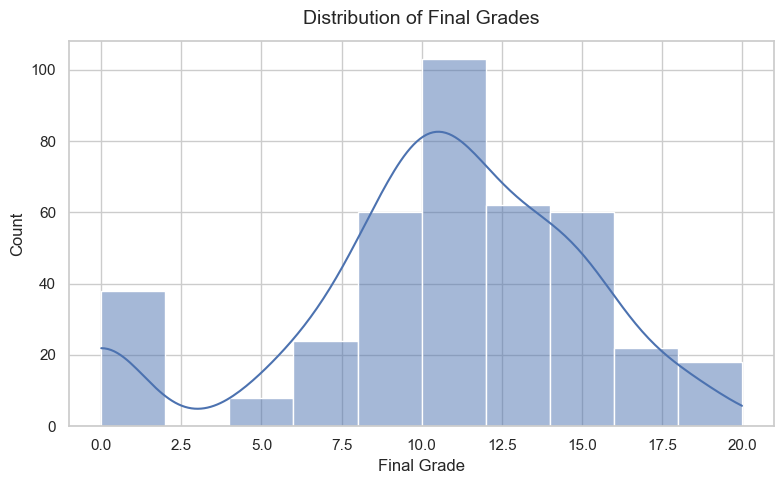

In [3]:
#Show distribution of final grades
plt.figure(figsize=(8, 5))
sns.histplot(df["G3"], bins=10, kde=True)

plt.title("Distribution of Final Grades", fontsize=14, pad=12)
plt.xlabel("Final Grade", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

## Relationship between Study Time and Academic Performance

We analyse how study time affects final grades by grouping students based on study time.

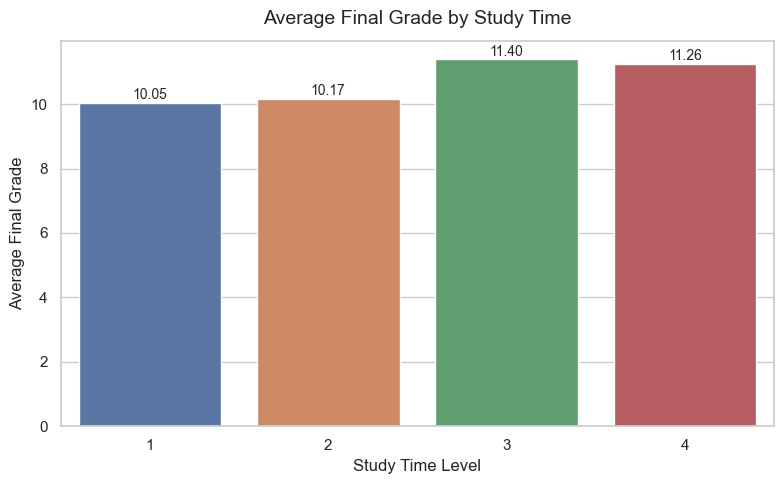

In [4]:
study_vs_grade = df.groupby("studytime", as_index=False)["G3"].mean()

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=study_vs_grade, x="studytime", y="G3")

ax.set_title("Average Final Grade by Study Time", fontsize=14, pad=12)
ax.set_xlabel("Study Time Level", fontsize=12)
ax.set_ylabel("Average Final Grade", fontsize=12)

for i, row in study_vs_grade.iterrows():
    ax.text(i, row["G3"] + 0.1, f"{row['G3']:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

**Insight:** Students with higher study time levels tend to achieve higher average final grades overall.

## Relationship between Absences and Final Grades
We examine whether absences impact student academic performance.

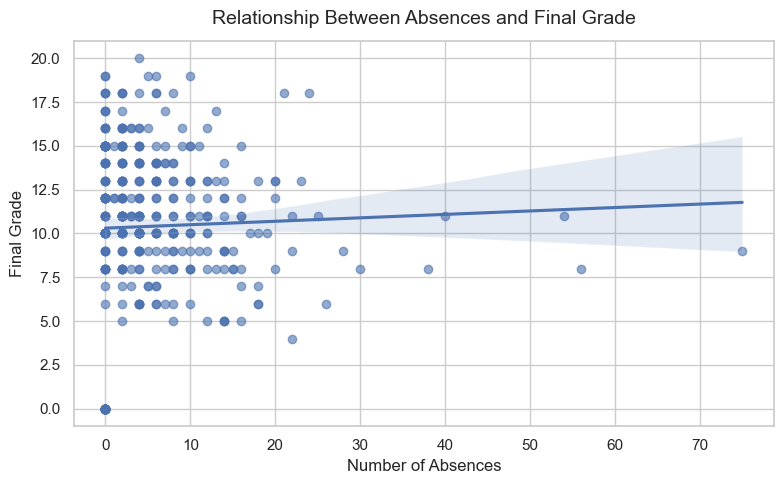

In [5]:
#Visualization of Relationship Between Absences and Final Grade
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="absences", y="G3", scatter_kws={"alpha": 0.6})

plt.title("Relationship Between Absences and Final Grade", fontsize=14, pad=12)
plt.xlabel("Number of Absences", fontsize=12)
plt.ylabel("Final Grade", fontsize=12)

plt.tight_layout()
plt.show()

**Insight:** There is a slight negative relationship between absences and final grades, indicating that higher absences may impact performance.

## Correlation Analysis


We analyse relationships between variables and final grades using correlation

In [6]:
correlation = df.corr(numeric_only=True)["G3"].sort_values(ascending=False)
print(correlation)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


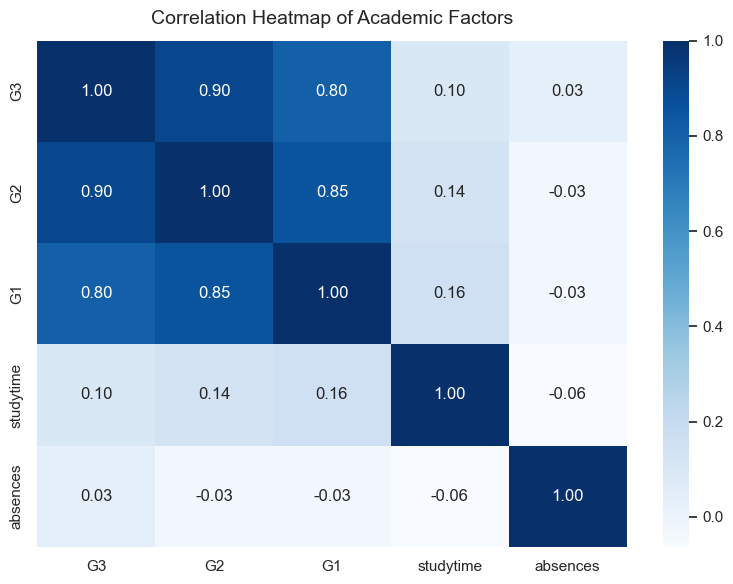

In [7]:
#Create Heatmap of Correlation between academic factors
plt.figure(figsize=(8, 6))
corr = df[["G3", "G2", "G1", "studytime", "absences"]].corr()


sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")

plt.title("Correlation Heatmap of Academic Factors", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

The correlation results show that study time has a positive relationship with final grades, while absences show a negative relationship. Previous grades (G1 and G2) have the strongest correlation with final performance.

## Key Insights

- Students with higher study time generally achieved better final grades
- Higher numbers of absences were associated with weaker academic performance
- Study habits and attendance both appear to influence student outcomes

## Conclusion

This analysis suggests that both study time and attendance are important factors in academic performance. Using Python, Pandas, and Seaborn, the project demonstrates how data analysis can be used to identify meaningful patterns in educational outcomes.